In [3]:
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import lightkurve as lk
import glob
import re
from astroquery import vizier

Matched 25 out of 43 IDs

EPIC ID           My P_rot  Cat P_rot
--------------------------------------
211964830           21.954     21.190
246193072           12.356     24.330
201855371           14.823     14.810
205117205            6.280      6.250
201497682           11.428     11.680
212178066            8.330      8.650
249826231           15.016     14.710
247418783           18.132     18.370
248527514           14.053     14.560
246876040           28.531     28.570
201677835           21.062     20.210
247589423           14.768     14.680
247267267            8.854      8.840
247887989           36.347     35.750
210797580           13.289     13.340
201208431           19.057     19.610
204129699           17.077     17.030
201912552           36.367     36.620
246472939           23.366     22.070
201833600           14.294     14.030
201460826           20.009     20.000
201205469            9.763      9.890
249801827           10.868     10.980
201757695           21.

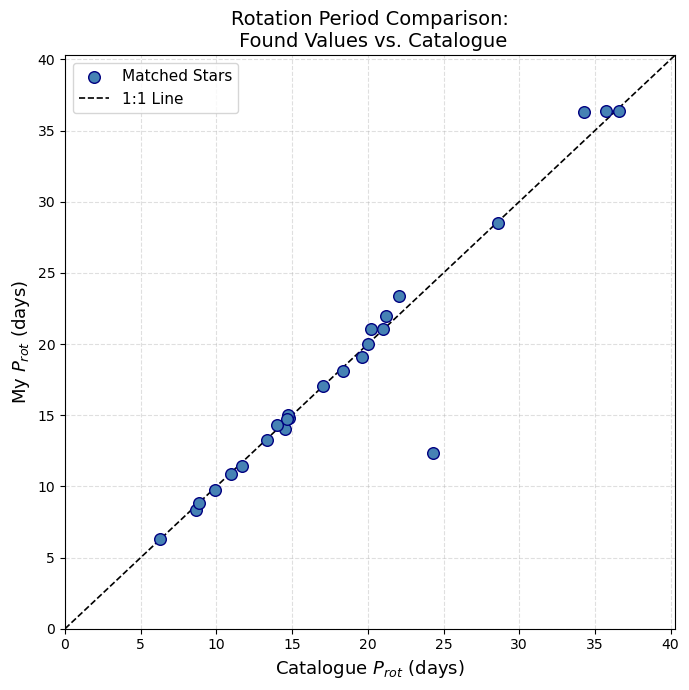

In [7]:
#Vetted K2IDs
vetted_ids = ['201613023', '211964830', '204890128', '246193072', '203826436', '201384232', '201855371', '205117205', '245950175', '249622103', '201498078', '201497682', '212178066', '201637175', '249826231', '201713348', '247418783', '246393474', '211414619', '248527514', '201862715', '246876040', '201338508', '248558190', '201677835', '201345483', '247589423', '201754305', '247267267', '247887989', '210797580', '201208431', '204129699', '201912552', '246472939', '201465501', '201833600', '201460826', '201205469', '248639308', '249801827', '201757695', '248861279']
#Vetted K2IDs Periods
vetted_periods = [15.393, 21.954, 23.218, 12.356, 12.226, 7.849, 14.823, 6.28, 12.356, 9.655, 18.794, 11.428, 8.33, 7.698, 15.016, 8.517, 18.132, 7.044, 4.338, 14.053, 6.562, 28.531, 13.341, 7.999, 21.062, 21.062, 14.768, 14.294, 8.854, 36.347, 13.289, 19.057, 17.077, 36.367, 23.366, 36.367, 14.294, 20.009, 9.763, 6.637, 10.868, 21.062, 36.279]
vetted_dict = dict(zip(vetted_ids, vetted_periods))

df = pd.read_csv(
    '/Users/iansterrett/Downloads/k2_nominal_prot.tsv',
    sep=';',
    comment='#',
    skipinitialspace=True
)

df.columns = df.columns.str.strip()
df = df[~df['EPIC'].astype(str).str.contains('-')]  # remove separator rows
df['EPIC'] = df['EPIC'].astype(str).str.strip()
df['Prot'] = pd.to_numeric(df['Prot'], errors='coerce')

matched_ids = []
my_periods = []
cat_periods = []

for epic_id, my_prot in vetted_dict.items():
    match = df[df['EPIC'] == epic_id]
    if not match.empty and not pd.isna(match['Prot'].values[0]):
        matched_ids.append(epic_id)
        my_periods.append(my_prot)
        cat_periods.append(match['Prot'].values[0])

print(f"Matched {len(matched_ids)} out of {len(vetted_ids)} IDs")
print(f"\n{'EPIC ID':<15} {'My P_rot':>10} {'Cat P_rot':>10}")
print("-" * 38)
for eid, mp, cp in zip(matched_ids, my_periods, cat_periods):
    print(f"{eid:<15} {mp:>10.3f} {cp:>10.3f}")


fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(cat_periods, my_periods, color='steelblue', edgecolors='navy', s=70, zorder=3, label='Matched Stars')

all_vals = my_periods + cat_periods
lim = (0, max(all_vals) * 1.1)
ax.plot(lim, lim, 'k--', linewidth=1.2, label='1:1 Line', zorder=2)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Catalogue $P_{rot}$ (days)', fontsize=13)
ax.set_ylabel('My $P_{rot}$ (days)', fontsize=13)
ax.set_title('Rotation Period Comparison:\n Found Values vs. Catalogue', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/prot_comparison.png', dpi=150)
print("\nPlot saved to prot_comparison.png")

In [11]:
from astroquery.mast import Catalogs
tic_id_list = []
#epic_id_list = ['201613023', '211964830', '204890128', '246193072', '203826436', '201384232', '201855371', '205117205', '245950175', '249622103', '201498078', '201497682', '212178066', '201637175', '249826231', '201713348', '247418783', '246393474', '211414619', '248527514', '201862715', '246876040', '201338508', '248558190', '201677835', '201345483', '247589423', '201754305', '247267267', '247887989', '210797580', '201208431', '204129699', '201912552', '246472939', '201465501', '201833600', '201460826', '201205469', '248639308', '249801827', '201757695', '248861279']
# Query TIC by EPIC ID (via coordinates or name)
epic_id_list = [210490365]
for epic_id in epic_id_list:
    result = Catalogs.query_object(f"EPIC{epic_id}", catalog="TIC", radius=0.001)
    tic_id = str(result['ID'][0])
    print(tic_id)
    tic_id_list.append(tic_id)

434226736


In [9]:
print(tic_id_list)

['396972464', '184914317', '49652731', '301258470', '68504570', '446672575', '291090078', '49040478', '4610830', '428820090', '281731203', '301610040', '175193677', '363445338', '335322931', '363445121', '27039476', '301235044', '323687123', '345063080', '380619414', '436575927', '38064757', '277869696', '397022282', '38087018', '18310799', '281886199', '5882269', '150096001', '456945304', '49462779', '50171060', '388804061', '422487869', '82050863', '363444743', '173090902', '443616612', '392817207', '432247315', '903075188', '61312205']


In [10]:
#Vetted TIC Ids Periods
['396972464', '184914317', '49652731', '301258470', '68504570', '446672575', '291090078', '49040478', '4610830', '428820090', '281731203', '301610040', '175193677', '363445338', '335322931', '363445121', '27039476', '301235044', '323687123', '345063080', '380619414', '436575927', '38064757', '277869696', '397022282', '38087018', '18310799', '281886199', '5882269', '150096001', '456945304', '49462779', '50171060', '388804061', '422487869', '82050863', '363444743', '173090902', '443616612', '392817207', '432247315', '903075188', '61312205']
#Vetted K2IDs Periods
[15.393, 21.954, 23.218, 12.356, 12.226, 7.849, 14.823, 6.28, 12.356, 9.655, 18.794, 11.428, 8.33, 7.698, 15.016, 8.517, 18.132, 7.044, 4.338, 14.053, 6.562, 28.531, 13.341, 7.999, 21.062, 21.062, 14.768, 14.294, 8.854, 36.347, 13.289, 19.057, 17.077, 36.367, 23.366, 36.367, 14.294, 20.009, 9.763, 6.637, 10.868, 21.062, 36.279]

[15.393,
 21.954,
 23.218,
 12.356,
 12.226,
 7.849,
 14.823,
 6.28,
 12.356,
 9.655,
 18.794,
 11.428,
 8.33,
 7.698,
 15.016,
 8.517,
 18.132,
 7.044,
 4.338,
 14.053,
 6.562,
 28.531,
 13.341,
 7.999,
 21.062,
 21.062,
 14.768,
 14.294,
 8.854,
 36.347,
 13.289,
 19.057,
 17.077,
 36.367,
 23.366,
 36.367,
 14.294,
 20.009,
 9.763,
 6.637,
 10.868,
 21.062,
 36.279]